# 读取模型，夹在模型权重。

In [1]:
import torch
from Model.DLSSNet.model_zhengjiao import Net
from Model.DLSSNet.args_zjBCIsingletrain_val import data_config
from torch.backends import cudnn
from einops import rearrange
import os
import torch.nn.functional as F
from scipy import io

cudnn.benchmark = False
cudnn.deterministic = True
subid = 7
model = Net(num_channels=data_config.num_channel, 
                    len_window=data_config.len_window, 
                    d_model=data_config.d_model, 
                    frame_stride=data_config.frame_stride,
                    num_frame=data_config.num_frame,
                    num_head=data_config.num_head, 
                    encoder_num_layers=data_config.encoder_num_layers, 
                    low_p = data_config.low_p,
                    dropout=data_config.dropout, 
                    transformerparwiseforward_dimrat=data_config.transformerparwiseforward_dimrat, 
                    statenum=data_config.statenum,
                    num_class=data_config.num_class)

device = torch.device("cpu")


target_category = 2  # set the class (class activation mapping)


path = 'C:\\2023Experiment\\parametersensitive\\单被试训练测试_matt数据_d_60\\BCICom_2a\\Conv+TransFormer+GPoolingV2+ClassTransHead+decoder+正交约束\\ON2024-11-22At13-10-37\\ckpl\\Fold'+str(subid).zfill(2)

# path = 'C:/2023Experiment/TrainingForanalysis/基群测试跨session/sub'+str(subid).zfill(2)+'/ckpl/State_num'+str(state_num).zfill(2)
cpkl_path = os.path.join(path, 'Conv+TransFormer+GPoolingV2+ClassTransHead+decoder+正交约束_best_params.pkl')
net_dict = torch.load(cpkl_path,map_location=device)
net_dict = net_dict['net_state_dict']
model.load_state_dict(net_dict)



data_path = 'C:/2023Experiment/DATA/BCICIV_2a_mat'


file_t = io.loadmat(os.path.join(data_path, 'BCIC_S' + f'{subid:02d}' + '_T.mat'))
file_e = io.loadmat(os.path.join(data_path, 'BCIC_S' + f'{subid:02d}' + '_E.mat'))

x_t = torch.Tensor(file_t['x_train'])
y_t = torch.Tensor(file_t['y_train']).view(-1)
x_e = torch.Tensor(file_e['x_test'])
y_e = torch.Tensor(file_e['y_test']).view(-1)

x_all = torch.concatenate([x_t, x_e], dim = 0)
y_all = torch.concatenate([y_t, y_e], dim = 0)

s = y_all.argsort()
x_all = x_all[s]
y_all = y_all[s]

dev = torch.device('cpu')

x_all = x_all[:, :, 124:562].to(dev)
y_all = y_all.long().to(dev)
model.eval()
with torch.no_grad():
    all_att, out, dec_x, embeded_x, basis, Pooled_x, Encoded_x, scaler, scores = model(x_all)

probabilities = F.softmax(out, dim=1)

# 获取最大概率的索引，即预测的类别
predictions = torch.argmax(probabilities, dim=1)

# 判断预测是否正确
correct = (predictions == y_all)

# # 过滤掉分类错误的样本
# correct_Pooled_x = Pooled_x[correct]
# # correct_Pooled_x = Pooled_x
# correct_labels = y_all[correct]
# # correct_labels = y_all
# correct_EmbededX = embeded_x[correct]
# correct_x_all = x_all[correct]
# # correct_EmbededX = embeded_x
# correct_Encoded_x = Encoded_x[correct]
# correct_scaler = scaler[correct]
# correct_scores = scores[correct]

# correct_Pooled_x = correct_Pooled_x.numpy()
# correct_EmbededX = correct_EmbededX.numpy()
# correct_Encoded_x = correct_Encoded_x.numpy()
# correct_scaler = correct_scaler.numpy()
# correct_x_all = correct_x_all.numpy()
# correct_scores = correct_scores.numpy()


# # 过滤掉分类错误的样本
correct_Pooled_x = Pooled_x
# correct_Pooled_x = Pooled_x
correct_labels = y_all
# correct_labels = y_all
correct_EmbededX = embeded_x
correct_x_all = x_all
# correct_EmbededX = embeded_x
correct_Encoded_x = Encoded_x
correct_scaler = scaler
correct_Pooled_x = correct_Pooled_x.numpy()
correct_EmbededX = correct_EmbededX.numpy()
correct_Encoded_x = correct_Encoded_x.numpy()
correct_scaler = correct_scaler.numpy()
correct_x_all = correct_x_all.numpy()

c:\ProgramData\anaconda3\envs\Pytorch2\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


(-103.69434852600098, 83.55685920715332, -65.22953815460205, 64.17513675689698)

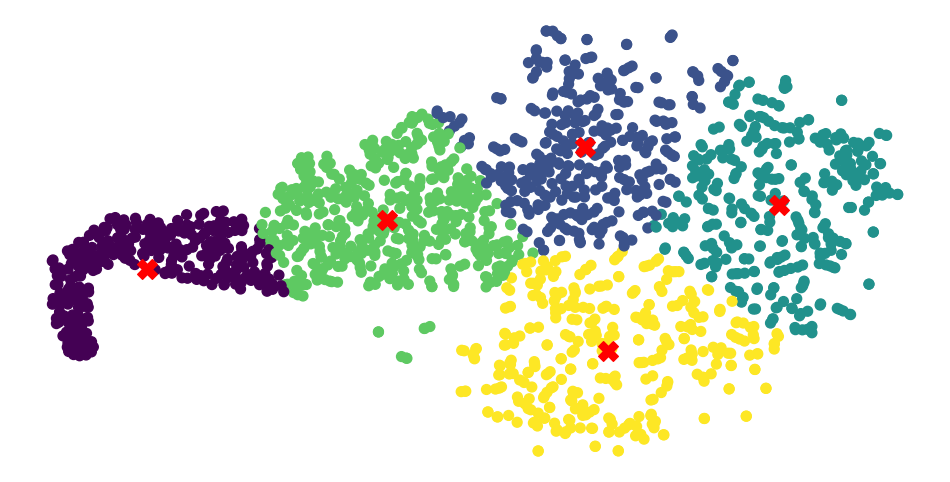

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


tsne = TSNE(n_components=2, random_state=40, method='exact')
T_correct_Pooled_x = []
# for i in range(correct_Pooled_x.shape[0]):
st = 3
ind = [st, st+144, st+288, st+432]
for i in ind:
    for j in range(correct_Pooled_x.shape[1]):
        T_correct_Pooled_x.append(correct_Pooled_x[i, j])

T_correct_Pooled_x = np.array(T_correct_Pooled_x)

kmeans = KMeans(n_clusters=5, random_state=42)

correct_Pooled_x_tsne = tsne.fit_transform(T_correct_Pooled_x)
y_kmeans = kmeans.fit_predict(correct_Pooled_x_tsne)



plt.figure(figsize=(12, 6))

plt.scatter(correct_Pooled_x_tsne[:, 0], correct_Pooled_x_tsne[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Cluster Centers')

plt.axis('off')
# plt.title('t-SNE Visualization of Correct')


# 

# tSNE可视化使用了任务相关放缩的特征序列。
先把每个样本的时间

In [2]:
import os
savepath = "C:/同步文件夹/2024-paper/图/动态分析/可分性d60/"
if os.path.exists(savepath) == False:
    os.mkdir(savepath)

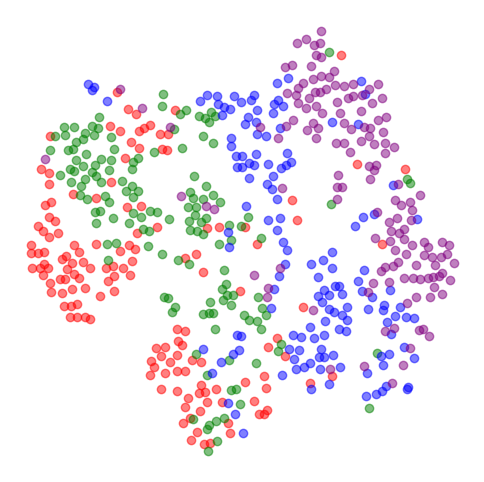

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

T_correct_EmbededX = np.mean(correct_EmbededX, axis = 1)
labels_np =correct_labels.numpy()
tsne = TSNE(n_components=2, random_state=40, method='exact')
correct_EmbededX_tsne = tsne.fit_transform(T_correct_EmbededX)

# 可视化结果
plt.figure(figsize=(6, 6))
colors = ['red', 'green', 'blue', 'purple']
tasks = ['left', 'right', 'foot', 'tongue']
for i in range(4):
    mask = labels_np == i
    plt.scatter(correct_EmbededX_tsne[mask, 0], correct_EmbededX_tsne[mask, 1], c=colors[i], label=tasks[i], alpha=0.5)

# plt.title('t-SNE Visualization of Embeded Data')

plt.axis('off')
plt.savefig(savepath+'subject'+str(subid).zfill(2)+'-all-SNEVisualizationofEmbededData.png', format='png', dpi=300) 
plt.show()

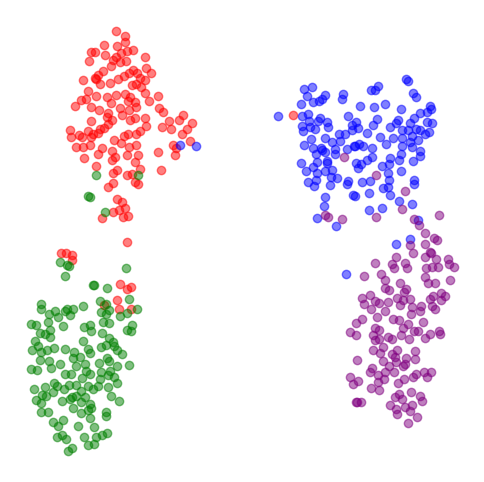

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

T_correct_Pooled_x = np.mean(correct_Pooled_x, axis = 1)
labels_np =correct_labels.detach().numpy()
tsne = TSNE(n_components=2,perplexity=30, random_state=40, method='exact')
correct_Pooled_x_tsne = tsne.fit_transform(T_correct_Pooled_x)

# 可视化结果
plt.figure(figsize=(6, 6))
colors = ['red', 'green', 'blue', 'purple']
tasks = ['left', 'right', 'foot', 'tongue']
for i in range(4):
    mask = labels_np == i
    plt.scatter(correct_Pooled_x_tsne[mask, 0], correct_Pooled_x_tsne[mask, 1], c=colors[i], label=tasks[i], alpha=0.5)

# plt.title('t-SNE Visualization of Pooled Embedded Data')
plt.axis('off')
plt.savefig(savepath+'subject'+str(subid).zfill(2)+'all'+'t-SNEVisualizationofPooledEmbededData.png', format='png', dpi=300) 
plt.show()

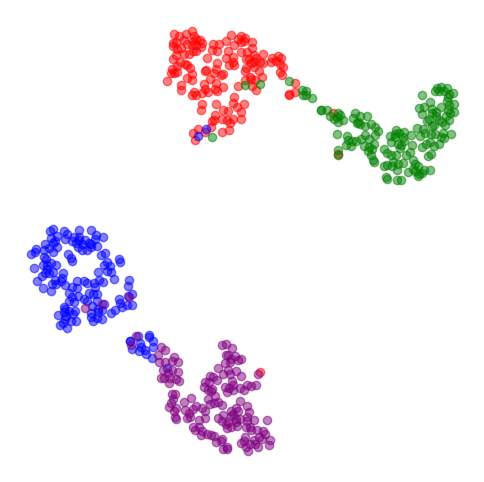

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

T_correct_Encoded_x = np.mean(correct_Encoded_x, axis = 1)
labels_np =correct_labels.detach().numpy()
tsne = TSNE(n_components=2, random_state=40, method='exact')
correct_Encoded_x_tsne = tsne.fit_transform(T_correct_Encoded_x)

# 可视化结果
plt.figure(figsize=(6, 6))
colors = ['red', 'green', 'blue', 'purple']
tasks = ['left', 'right', 'foot', 'tongue']
for i in range(4):
    mask = labels_np == i
    plt.scatter(correct_Encoded_x_tsne[mask, 0], correct_Encoded_x_tsne[mask, 1], c=colors[i], label=tasks[i], alpha=0.5)

# plt.title('t-SNE Visualization of Encoded Pooled Embeded Data')

plt.axis('off')
plt.savefig(savepath+'subject'+str(subid).zfill(2)+'-all-SNEVisualizationofEncodedPooledEmbededData.png', format='png', dpi=300) 
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn import datasets
# from sklearn.manifold import TSNE

# # 加载数据集，这里以MNIST手写数字为例
# digits = datasets.load_digits()
# X = digits.data  # 图像的像素值
# y = digits.target  # 对应的数字标签
# # 
# # 选择t-SNE模型并设置参数
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)

# # 应用t-SNE算法降维
# X_tsne = tsne.fit_transform(X)

# # 可视化结果
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6)
# plt.colorbar(scatter)
# plt.title('t-SNE visualization of MNIST digits')
# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
# plt.show()

In [ ]:
import numpy as np
from mne import create_info, concatenate_raws, EpochsArray
from mne.channels import make_standard_montage
import matplotlib.pyplot as plt
from mne.io import RawArray

min_val = np.min(correct_EmbededX)
max_val = np.max(correct_EmbededX)
scaled_correct_EmbededX = (correct_EmbededX - min_val) / (max_val - min_val)
min_val = np.min(correct_Pooled_x)
max_val = np.max(correct_Pooled_x)
scaled_correct_Pooled_x = (correct_Pooled_x - min_val) / (max_val - min_val)
# scaled_correct_Pooled_x = scaled_correct_Pooled_x- np.mean(scaled_correct_Pooled_x)

it = 2
data = scaled_correct_Pooled_x[it].T
ch_names = [f'pattern{i+1}' for i in range(data.shape[0])]  # 通道名称
# ch_names.append('Task_Related')
ch_types = ['eeg'] * data.shape[0]  # 通道类型
sfreq = 64  # 采样频率
info = create_info(ch_names=ch_names, ch_types=ch_types, sfreq=sfreq)
raw = RawArray(data, info)
raw.plot(n_channels=data.shape[0], scalings='auto', title='EEG Signal')
plt.show()

basis_m = torch.transpose(basis, -1, -2)
basis_m = basis_m[correct]
x = torch.tensor(correct_Pooled_x)

xonbasis  = torch.bmm(x, basis_m)
data = xonbasis[it].T
data = torch.concatenate([data, scaler[it].unsqueeze(0)],dim = 0)
ch_names = [f'pattern{i+1}' for i in range(data.shape[0]-1)]  # 通道名称
ch_names.append('Task_Related')
ch_types = ['eeg'] * data.shape[0]  # 通道类型
sfreq = 64  # 采样频率为1000Hz
info = create_info(ch_names=ch_names, ch_types=ch_types, sfreq=sfreq)
raw = RawArray(data, info)
raw.plot(n_channels=data.shape[0], scalings='auto', title='EEG Signal')
plt.show()

# xonbasis = all_att['decoder_attn'][it]
# data = xonbasis[it].T
# data = torch.concatenate([data, scaler[it].unsqueeze(0)],dim = 0)
# ch_names = [f'pattern{i+1}' for i in range(data.shape[0]-1)]  # 通道名称
# ch_names.append('Task_Related')
# ch_types = ['eeg'] * data.shape[0]  # 通道类型
# sfreq = 64  # 采样频率为1000Hz
# info = create_info(ch_names=ch_names, ch_types=ch_types, sfreq=sfreq)
# raw = RawArray(data, info)
# raw.plot(n_channels=data.shape[0], scalings='auto', title='EEG Signal')
# plt.show()

In [ ]:
import seaborn 
import matplotlib.pyplot as plt
import numpy as np

i = 0

y_axis =correct_scaler[i]
x_axis = np.arange(0, len(y_axis))
centers = np.arange(0.5, len(y_axis), 1)  # 热力图中心横坐标的数组

plt.figure(figsize=(20, 6))
data = correct_Pooled_x[i].T
# seaborn.heatmap(correct_EmbededX[i].T, vmin=0, vmax=1)
plt.imshow(data, cmap='RdBu_r', aspect='auto',  vmin=0, vmax=1,extent=[0, len(y_axis), -1, 64]) 
plt.colorbar() 
plt.plot(centers, y_axis*3-5, color='blue', marker='*', linestyle='-')
plt.plot(centers, np.ones_like(centers)*(-5))


# 添加标题和标签
plt.title('Example Line Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.figure(figsize=(20, 6))
data = xonbasis[it].T
# seaborn.heatmap(correct_EmbededX[i].T, vmin=0, vmax=1)
plt.imshow(data, cmap='RdBu_r', aspect='auto',  vmin=0.5, vmax=1,extent=[0, len(y_axis), -1, 23]) 
plt.colorbar() 
plt.plot(centers, y_axis*2-3, color='blue', marker='*', linestyle='-')
plt.plot(centers, np.ones_like(centers)*(-3))


# 添加标题和标签
plt.title('Example Line Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

# 显示图形
plt.show()
# seaborn.heatmap(np.expand_dims(correct_scaler[i], axis=0), vmin=0, vmax=1)
# plt.show()
plt.figure(figsize=(10, 0.6))
seaborn.heatmap(correct_Pooled_x[i].T, vmin=0, vmax=1)
plt.show()
plt.figure(figsize=(10, 6))
seaborn.heatmap(correct_x_all[i])
plt.show()
